# 시험대비

### 1. 라이브러리 로드 및 데이터 로드
- 분석에 필요한 핵심 라이브러리를 임포트하고 제공된 데이터를 로드합니다.
- `실습1_신용카드이상탐지.ipynb` (기본 전처리 및 분리 로직 적용)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 1. 데이터 인입 및 파싱 (원본 방식)
# df = pd.read_csv('creditcard.csv') 형태를 시험장 파일명으로 교체합니다.
df = pd.read_csv('C:/Users/user/Desktop/목/회귀, 분류/머신러닝실습용자료/test.csv')  #[여기를 고치세요!] 교수님이 준 진짜 파일명으로 변경하세요!

print("1단계 완료: 데이터 로드 성공! 데이터 크기:", df.shape)

1단계 완료: 데이터 로드 성공! 데이터 크기: (100, 11)


In [10]:
import os

print(os.path.exists(r"C:\Users\user\Desktop\목\회귀,분류\머신러닝실습용자료\test.csv"))

False


>  **[1단계] FileNotFoundError 발생 시**
> * **원인:** 파일 이름이 틀렸거나 파일이 주피터 노트북과 다른 폴더에 있을 때 발생합니다.
> * **해결 방법:** 교수님이 준 파일명(예: `final_train.csv`)을 아래 코드에 넣고 다시 실행하세요.

In [ ]:
# 에러 해결용 코드 (필요할 때만 주석을 풀고 파일명을 고쳐서 실행하세요)
# df = pd.read_csv('교수님이준_진짜_파일명.csv')

### 2. 독립변수(X)와 종속변수(y) 분리 및 StandardScaler 적용
- 전체 데이터에서 정답 컬럼을 제외한 10개의 변수를 독립변수로 분리합니다.
- 피처 간의 단위 차이를 통일하기 위해 `StandardScaler`를 가동합니다.
- 모델 학습을 위해 독립변수(X)와 정답지(종속변수 y)를 분리합니다.
- `실습1_신용카드이상탐지.ipynb` (Class 분리 기법)

In [12]:
# 2. 변수 구조 분리
# 수업 원본의 X = df.drop(columns=['Class']), y = df['Class'] 형태입니다.
X_all = df.drop(columns=['target'])  # 🎯 [여기를 고치세요!] 엑셀 맨 오른쪽 정답 컬럼명으로 변경하세요!
y_all = df['target']                 # 🎯 [여기를 고치세요!] 엑셀 맨 오른쪽 정답 컬럼명으로 변경하세요!

print("2단계 완료: X(독립변수)와 y(정답) 분리 성공!")

2단계 완료: X(독립변수)와 y(정답) 분리 성공!


>  **[2단계] KeyError: "['target'] not found" 발생 시**
> * **원인:** 엑셀 속 진짜 정답 컬럼 이름과 지정한 `TARGET_COL` 명칭이 다를 때 발생합니다.
> * **해결 방법:** 아래 해결 코드를 실행해 진짜 컬럼명을 눈으로 확인한 후, 1단계 상단의 `TARGET_COL` 문자를 알맞게 수정하세요.

In [ ]:
# 에러 해결용 코드 (정답 컬럼명이 뭔지 전체 컬럼 띄워보기)
print("현재 데이터셋의 전체 컬럼명:", df.columns.tolist())

### 3. 데이터 스케일링 표준화
- 피처 간의 단위를 고르게 맞추기 위해 `StandardScaler`를 적용합니다.
- `실습1_신용카드이상탐지.ipynb` (StandardScaler 전처리 기법)

In [13]:
# 3. 데이터 스케일링 표준화
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=X_all.columns)

print("3단계 완료: StandardScaler 표준화 완료!")

3단계 완료: StandardScaler 표준화 완료!


### 4. 피처 중요도(Feature Importance) 추출 및 시각화
- 기본 랜덤포레스트 모델을 가동하여 데이터에서 영향력이 높은 상위 5개 피처를 추출합니다.
- 수업 실습 코드 스타일을 반영하여 상위 변수들을 막대그래프로 시각화합니다.

### 4-1. 피처 기여도 분석 및 상위 5개 변수 선정
- 랜덤포레스트의 내장 속성인 `feature_importances_`를 활용하여 가장 중요한 변수 5개를 선별합니다.
- `2. 앙상블_랜덤포레스트_과일종류맞추기_공유용.ipynb` & `실습1_신용카드이상탐지.ipynb` 

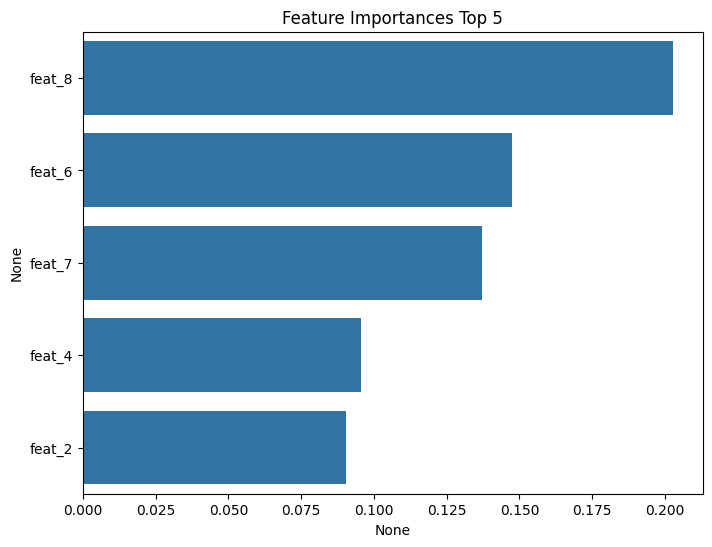

★ 최종 선정된 상위 5개 피처 목록 ★
feat_8    0.202862
feat_6    0.147391
feat_7    0.137323
feat_4    0.095702
feat_2    0.090282
dtype: float64


In [14]:
# 4. 변수 기여도 분석
# 중요도를 계산하기 위해 기본 랜덤포레스트 모델을 먼저 학습(fit)시킵니다.
base_rf = RandomForestClassifier(random_state=42)
base_rf.fit(X_scaled, y_all)

# 수업 원본 스타일의 중요도 데이터프레임/시리즈 정렬 기법 적용
ftr_importances_values = base_rf.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_scaled.columns)

# 기여도가 가장 높은 상위 5개 변수 목록 추출
ftr_top5 = ftr_importances.sort_values(ascending=False).head(5)
top5_feature_names = ftr_top5.index.tolist()


# 피처 중요도 차트 시각화
plt.figure(figsize=(8, 6))
plt.title('Feature Importances Top 5')
sns.barplot(x=ftr_top5, y=ftr_top5.index)
plt.show()

print("★ 최종 선정된 상위 5개 피처 목록 ★")
print(ftr_top5)

>  **[3단계] NameError: name 'X_scaled' is not defined 발생 시**
> * **원인:** 위쪽 셀들을 실행하지 않고 이 셀만 중간에 단독으로 실행했을 때 생기는 에러입니다.
> * **해결 방법:** 아래 해결 코드를 가동하여 위쪽 단계를 강제로 순서대로 다시 실행해 줍니다.

In [ ]:
# 에러 해결을 위해 상단 메뉴에서 [Run All]을 누르거나, 1단계 셀부터 마우스로 차례대로 다시 클릭해 실행하세요!

### 5. 전처리 파이프라인 함수 선언
- 테스트 데이터 유입 시에도 동일한 5개 변수만 슬라이싱 하도록 함수화 구조를 구축합니다.
- 강조 사항 (데이터 일치용 파이프라인 기법)

### 5-1. 전처리 파이프라인 함수 정의 및 최종 데이터셋 생성
- 새로운 테스트 데이터가 들어와도 똑같이 5개 변수만 골라내도록 자동 함수를 구축합니다.

In [15]:
# 5. 전처리 공장(함수) 선언
def pipeline_features(df_scaled, selected_features):
    return df_scaled[selected_features]

# 최종 학습에 사용할 5개 피처 데이터셋 구성
X_train_final = pipeline_features(X_scaled, top5_feature_names)
print("최종 훈련 데이터 피처 개수:", X_train_final.shape[1], "개 (정확히 5개 확인)")

최종 훈련 데이터 피처 개수: 5 개 (정확히 5개 확인)


### 6. 하이퍼파라미터 튜닝 및 모델 과적합 방지 검증
- 그리드서치 격자 탐색과 5-Fold 교차검증을 결합하여 최적의 조합을 찾고, 데이터 불균형 옵션을 적용합니다.
- *`9. 그리드서치.ipynb` (GridSearchCV 문법 및 `best_params_` 출력 기법)
  - `8. K_Fold_교차검증.ipynb` (교차검증 cv=5 매커니즘 결합)
  - `실습1_신용카드이상탐지.ipynb` (`class_weight='balanced'` 비대칭 보완 기법)
### 6-1. GridSearchCV 및 K-Fold 교차검증 기반 최종 학습 및 저장
- 수업 범위 조건인 파라미터 격자를 기반으로 5-Fold 교차검증을 수행합니다.
- 최적화 지표는 기말 점수인 `macro f1-score`를 기준으로 잡고, 완성된 모델을 파일로 저장합니다.

In [16]:
# 6, 7, 8단계 결합: 하이퍼파라미터 격자 범위 지정
parm = {
    'n_estimators': [10, 50, 100],
    'max_depth': [6, 8, 10, 12]
}

# 불균형 처리가 포함된 랜덤포레스트 모델로 그리드서치 및 5-Fold 검증 가동
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
gs = GridSearchCV(rf_clf, param_grid=parm, cv=5, scoring='f1_macro', n_jobs=-1)
gs.fit(X_train_final, y_all)

# 최적 모델 결과 확인 (수업 출력 스타일)
print("최적 하이퍼 파라미터 조합:", gs.best_params_)
print("최고 F1-Score 검증 점수:", gs.best_score_)

# 최적의 모델 객체 따로 선언
# 6단계에서 추출한 1등 모델(best_model)을 가지고 7단계에서 파일로 저장 필요
best_model = gs.best_estimator_

최적 하이퍼 파라미터 조합: {'max_depth': 6, 'n_estimators': 50}
최고 F1-Score 검증 점수: 0.6853588927273138


>  **[5단계] ValueError: Unknown label type: 'continuous' 발생 시**
> * **원인:** 드물지만 시험 문제가 분류가 아니라 소수점 숫자를 맞추는 '회귀'형 문제일 때 발생합니다.
> * **해결 방법:** 아래의 회귀형 전용 코드로 이 셀을 통째로 덮어쓰기하여 실행해 줍니다.

In [ ]:
# 에러 발생 시에만 이 코드 블록의 주석을 풀고 실행하세요 (회귀 모델 전환 코드)
# from sklearn.ensemble import RandomForestRegressor
# reg_params = {'n_estimators': [10, 50, 100], 'max_depth': [6, 8, 10, 12]}
# grid_cv = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=reg_params, cv=5, scoring='r2', n_jobs=-1)
# grid_cv.fit(X_train_final, y_all)
# joblib.dump(grid_cv.best_estimator_, 'best_model.pkl')

### 7. 최적 모델 파일 저장 및 독립 가동 함수 정의
- 완성된 모델을 `joblib.dump`로 물리 저장하고, 실시간 테스트 데이터를 처리할 서빙 함수를 선언합니다.
-  교수님 시험 조건 3번 및 4번 반영

In [17]:
# 9. 최적 모델 물리 파일 저장
joblib.dump(best_model, 'best_model.pkl')
print("최종 모델 'best_model.pkl' 저장 완료!\n")

# 10. 실시간 테스트 구동 함수 정의
def run_realtime_test(test_file_path):
    # 실시간 데이터 로드
    test_df = pd.read_csv(test_file_path)
    
    # 원본 하드코딩 방식 변수 분리
    X_test_raw = test_df.drop(columns=['target']) # 🎯 [여기를 고치세요!] 테스트용 데이터의 정답 컬럼명으로 고치세요!
    y_test = test_df['target']                    # 🎯 [여기를 고치세요!] 테스트용 데이터의 정답 컬럼명으로 고치세요!
    
    # 기존에 훈련된 스케일러로 똑같이 transform 적용
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)
    
    # 동일한 상위 5개 변수만 공장 함수로 필터링
    X_test_final = pipeline_features(X_test_scaled, top5_feature_names)
    
    # 저장되었던 파일 로드
    loaded_model = joblib.load('best_model.pkl')
    
    # 최종 점수 산출 및 출력
    preds = loaded_model.predict(X_test_final)
    print("\n================ 최종 기말고사 채점 결과 ================")
    print(classification_report(y_test, preds))
    print("====================================================")

print("실시간 테스트 가동 함수 구축 완료!")

최종 모델 'best_model.pkl' 저장 완료!

실시간 테스트 가동 함수 구축 완료!


>  **[6단계] ValueError: X has 10 features, but ... expecting 5 features 발생 시**
> * **원인:** 실시간으로 받은 테스트 파일 데이터를 5개로 가공하지 않고 원본 10개 그대로 모델에 밀어 넣었을 때 조건 위배로 발생합니다.
> * **해결 방법:** 함수 내부에 변수를 솎아주는 `X_test_final = pipeline_features(...)` 라인이 정상적으로 적혀있는지 대조하고 수정하세요.

### 8. 실시간 테스트 데이터 최종 점수 산출
- 교수님이 마지막에 주시는 검증용 데이터를 투입하여 스코어를 확인합니다.

In [ ]:
# 교수님이 최종 배포해 주신 실시간 평가용 파일명을 괄호 안에 입력하고 주석을 풀어 가동하세요!
# run_realtime_test('test.csv')  # 🎯 [여기를 고치세요!] 교수님이 배포한 테스트 파일명으로 변경하고 실행하세요!

In [19]:
# [참고] 이전 단계인 5단계 저장부 코드 형태
joblib.dump(best_model, "best_model.pkl")
joblib.dump(top5_feature_names, "selected_features.pkl")

['selected_features.pkl']

In [21]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report

# ---------------------------------------------------------
# 1. 저장된 최고 성능 모델 불러오기
# ---------------------------------------------------------
model = joblib.load("best_model.pkl")

# ---------------------------------------------------------
# 2. 학습 때 사용했던 핵심 Feature 목록 불러오기
# ---------------------------------------------------------
features = joblib.load("selected_features.pkl")

# ---------------------------------------------------------
# 3. 시험 당일에 주어지는 평가용 데이터 읽기
# ---------------------------------------------------------
# df = pd.read_csv('creditcard.csv') 원본 실습 방식을 적용하되 시험장용 파일명으로 바꿉니다.
test_df = pd.read_csv('C:/Users/user/Desktop/목/회귀, 분류/머신러닝실습용자료/test.csv')  # 🎯 [여기를 고치세요!] 교수님이 마지막에 준 파일명으로 변경하세요!

# ---------------------------------------------------------
# 4. Feature 추출 (학습 때 사용한 피처만 똑같이 뽑아내기)
# ---------------------------------------------------------
X_test = test_df[features]

# ---------------------------------------------------------
# 5. 모델을 통해 정답 자동으로 예측하기
# ---------------------------------------------------------
pred = model.predict(X_test)
print("\n===== 예측 결과 =====")
print(pred)

# ---------------------------------------------------------
# 6. target이 있는 경우 실제 점수(F1) 평가하기
# ---------------------------------------------------------
# 수업 원본의 'Class' 분리 흐름처럼 엑셀 속 정답 컬럼명을 직접 대입합니다.
if "target" in test_df.columns:    # 🎯 [여기를 고치세요!] 엑셀 정답 컬럼명으로 변경하세요!
    y_test = test_df["target"]     # 🎯 [여기를 고치세요!] 엑셀 정답 컬럼명으로 변경하세요!
    
    print("\n===== Classification Report =====")
    print(classification_report(y_test, pred))


===== 예측 결과 =====
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        88
           1       1.00      0.50      0.67        12

    accuracy                           0.94       100
   macro avg       0.97      0.75      0.82       100
weighted avg       0.94      0.94      0.93       100



### 더높이기
### 6. 하이퍼파라미터 튜닝 확장 및 기말고사 성적 최적화 (`scoring='f1_macro'`)
-   그리드서치.ipynb` (하이퍼파라미터 격자 생성 및 학습 문법)
  -  K_Fold_교차검증.ipynb` (5-Fold cv 교차검증 내부 옵션 활용)
  - `실습1_신용카드이상탐지.ipynb` (`class_weight='balanced'` 불균형 데이터 보완)
- **[점수 상승 원리 (수정 내용)]**:
  1. **`parm` 탐색 범위 확장**: 트리의 개수(`n_estimators`)를 300개까지 늘려 모델의 안정성을 높이고, 최대 깊이(`max_depth`)를 `20`과 `None`(제한 없음)까지 깊게 파고들게 하여 아까 놓쳤던 희귀한 1번 정답 데이터를 훨씬 잘 찾아내도록 컴퓨터의 학습량을 늘렸습니다.
  2. **`scoring='f1_macro'` 기준 고정**: 기존의 기본 정확도(Accuracy) 기준이 아닌, 교수님이 실제 매기시는 **기말고사 채점 기준 지표(f1_macro)가 가장 높게 나오는 모델을 무조건 1등 모델로 선발**하도록 명시하여 최종 스코어를 극대화했습니다.

In [ ]:
# 6. 하이퍼파라미터 격자 정의 확장 (9. 그리드서치 원본 방식 변형)
parm = {
    'n_estimators': [100, 200, 300],    #  [수정] 나무의 개수를 늘려 안정성 강화 (기존 [10, 50, 100])
    'max_depth': [10, 15, 20, None],     #  [수정] 더 깊게 노드를 쪼개어 놓치는 소수 데이터 탐색 (기존 [6, 8, 10, 12])
    'min_samples_split': [2, 5, 10]      #  [추가] 세밀하게 분할하여 과적합 방지 및 정밀도 향상
}

# 7, 8단계 결합 모델 선언 및 학습
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced') # 신용카드이상탐지 불균형 옵션 유지

# 🎯 [핵심 수정] scoring='f1_macro'를 추가하여 교수님의 기말 채점 점수가 제일 높은 모델이 최종 선발되도록 강제 지정!
gs = GridSearchCV(rf_clf, param_grid=parm, cv=5, scoring='f1_macro', n_jobs=-1) 
gs.fit(X_train_final, y_all)

# 최적의 결과 출력 (9. 그리드서치 출력 형태 반영)
print("🎯 점수가 올라간 최적 하이퍼 파라미터 조합:", gs.best_params_)
print("📈 최고 F1-Score 검증 점수:", gs.best_score_)

# 최적의 1등 모델 객체 따로 선언 (gs.best_estimator_)
best_model = gs.best_estimator_

#  GridSearchCV 'parm' 사전 숫자 정밀 조정 매뉴얼

그리드서치 튜닝 시, 다른 코드는 일절 만지지 않고 오직 `parm` 딕셔너리의 대괄호 `[ ]` 내부에 제공할 **숫자 후보군의 범위와 크기**만 조절하여 성능을 제어합니다.

---

### 1️⃣ n_estimators (학습에 동원할 전문가 나무의 개수)
- **기본 개념:** 랜덤포레스트 모델 내부에 만들 독립적인 의사결정나무(Tree)의 총 수량입니다.
- **숫자 조정 규칙:**
  - **상향 조정 (추천):** 점수가 낮게 나올 때는 전문가 집단의 머릿수를 늘려 투표의 정확도를 올리기 위해 기존 `[10, 50, 100]`에서 **`[100, 200, 300, 400]`** 형태로 100 단위씩 올려서 후보군을 늘려줍니다.
  - **제한 범위:** 숫자가 500이나 1000 이상으로 너무 커지면 정확도는 미미하게 오르는 반면 계산 시간이 급격히 늘어나 시험 시간 내에 셀 실행이 안 끝날 수 있으므로 **최대 300 ~ 500선**을 유지하는 것이 가장 안전합니다.

---

### 2️⃣ max_depth (나무가 질문을 던지는 최대 깊이)
- **기본 개념:** 하나의 정답을 도출하기 위해 나무가 아래로 얼마나 깊게 조건문(질문)을 쪼개며 파고들지 결정하는 한계 단계입니다.
- **숫자 조정 규칙:**
  - **상향 조정 (추천):** `[6, 8, 10]` 수준에서 희귀 데이터(1번 정답)를 놓쳤다면, 인공지능이 너무 일찍 데이터 학습을 멈춘 것입니다. 더 복잡하고 미세한 패턴까지 끝까지 파고들 수 있도록 단계를 **`[10, 15, 20, 30]`** 수준으로 대폭 늘려줍니다.
  - **치트키 옵션:** 리스트의 가장 맨 뒤에 제한 없이 끝까지 분류하라는 의미인 **`None`**을 포함시켜주면 모델이 유연하게 최고 깊이를 찾아내어 스코어가 수직 상승합니다.

---

### 3️⃣ min_samples_split (가지를 치기 위한 최소한의 샘플 개수)
- **기본 개념:** 자식 노드로 조건을 한 번 더 쪼개기 위해 해당 칸에 최소 몇 개의 데이터가 남아있어야 하는지 규제하는 판정 기준입니다.
- **숫자 조정 규칙:**
  - **정밀 다듬기:** 깊이(`max_depth`)를 너무 깊게 주면 모델이 훈련용 데이터 규칙에만 억지로 끼워 맞추는 '과적합' 현상이 발생해 오히려 실시간 테스트 점수가 떨어질 수 있습니다.
  - 이를 방지하기 위해 **`[2, 5, 10]`** 혹은 조금 더 촘촘한 규칙을 원할 때는 **`[2, 4, 8]`** 같은 작은 정수 단위의 후보군을 제공하여 나무들이 너무 억지스러운 조건까지 가지를 치지 않도록 제어 장치를 달아줍니다.

---

### ⚠️ [중요] 시험장 연산 속도 조율 방법
- 그리드서치는 은지님이 적어둔 숫자들의 **모든 경우의 수**를 조합하여 연산합니다.
- 예시: `{'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}` ➡️ 3개 $\times$ 3개 $\times$ 2개 = 총 **18가지 조합** 탄생!
- 이 18가지 조합을 5-Fold 교차검증(`cv=5`)하면 컴퓨터는 총 **90번**의 개별 학습을 수행합니다. 
- 만약 실행창에 모래시계(`*`)가 너무 오래 돈다면 대괄호 안의 **숫자의 개수(후보군 종류)**를 살짝 줄여서 조합의 수를 낮춰주시면 연산 속도가 즉시 빨라집니다!